# Classification Tasks

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier, AdaBoostClassifier, BaggingClassifier

SEED = 10

In [7]:
# Load the wine dataset
wine = load_wine(as_frame=True)
df = wine.frame


# Check which two features are the most important for classification

# Binary target variable: 1 if class_0, 0 otherwise
df["target_binary"] = (df["target"] == 0).astype(int)

feature_cols = wine.feature_names
correlations = df[feature_cols].apply(lambda x: x.corr(df["target_binary"])).abs()
top_features = correlations.sort_values(ascending=False)

selected_features = top_features.index[:2]
print(f"Selected features for classification: {selected_features.tolist()}")

Selected features for classification: ['proline', 'flavanoids']


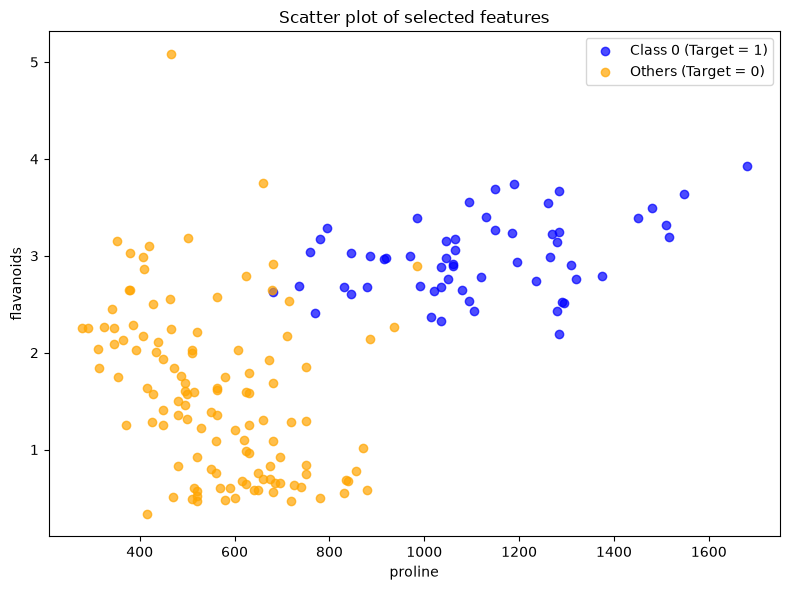

In [8]:
# Validate the selected features by visualizing the data
plt.figure(figsize=(8, 6))
plt.scatter(
    df[df["target_binary"] == 1][selected_features[0]],
    df[df["target_binary"] == 1][selected_features[1]],
    color='blue', label='Class 0 (Target = 1)', alpha=0.7
)

plt.scatter(
    df[df["target_binary"] == 0][selected_features[0]],
    df[df["target_binary"] == 0][selected_features[1]],
    color='orange', label='Others (Target = 0)', alpha=0.7
)

plt.xlabel(selected_features[0])
plt.ylabel(selected_features[1])
plt.title('Scatter plot of selected features')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Create X and y
X = df[selected_features]
y = df["target_binary"]

In [10]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

In [12]:
from visualizations import plot_labeled_decision_regions

## Decision Boundary Visualization for Decision Tree Classifier and Logistic Regression


/home/omer-yaslitas/projects/datacamp-ml-track/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/omer-yaslitas/projects/datacamp-ml-track/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


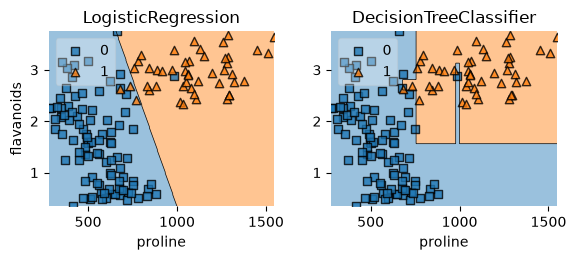

In [ ]:
logreg = LogisticRegression(random_state=SEED, max_iter=1000)
logreg.fit(X_train, y_train)

dt = DecisionTreeClassifier(random_state=SEED)
dt.fit(X_train, y_train)

classifiers = [logreg, dt]

plot_labeled_decision_regions(X_train, y_train, classifiers)

In [ ]:
# Use all features now
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

In [19]:
# Gini vs Entropy : Decision Trees impurtance of splitting criteria
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=SEED)
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=SEED)

dt_gini.fit(X_train, y_train)
dt_entropy.fit(X_train, y_train)

accuracy_gini = accuracy_score(y_test, dt_gini.predict(X_test))
accuracy_entropy = accuracy_score(y_test, dt_entropy.predict(X_test))

print(f"Accuracy (Gini): {accuracy_gini:.4f}")
print(f"Accuracy (Entropy): {accuracy_entropy:.4f}")

Accuracy (Gini): 0.9444
Accuracy (Entropy): 0.9722


## Ensemble Learning

In [33]:
from sklearn.datasets import fetch_covtype

covtype = fetch_covtype(as_frame=True)
df_covtype = covtype.frame

# Get 15000 samples for faster training
df_covtype_sampled = df_covtype.sample(n=15000, random_state=SEED)
X = df_covtype_sampled.drop(columns='Cover_Type')
y = df_covtype_sampled['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
lr = LogisticRegression(random_state=SEED, max_iter=3000)
knn = KNeighborsClassifier(n_neighbors=27)
dt = DecisionTreeClassifier(random_state=SEED)

ensemble_clfs = [
    ('Logistic Regression', lr),
    ('K-Nearest Neighbors', knn),
    ('Decision Tree', dt)
]

for name, clf in ensemble_clfs:
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy ({name}): {accuracy:.4f}")

Accuracy (Logistic Regression): 0.7297
Accuracy (K-Nearest Neighbors): 0.7240
Accuracy (Decision Tree): 0.7357


### Voting Classifier

In [36]:
vc = VotingClassifier(estimators=ensemble_clfs, voting='hard')
vc.fit(X_train_scaled, y_train)
y_pred_vc = vc.predict(X_test_scaled)
accuracy_vc = accuracy_score(y_test, y_pred_vc)
print(f"Accuracy (Voting Classifier): {accuracy_vc:.4f}")

Accuracy (Voting Classifier): 0.7640


### Bagging Classifier and OOB Score

In [37]:
dt_single = DecisionTreeClassifier(random_state=SEED)
dt_single.fit(X_train_scaled, y_train)
y_pred_single = dt_single.predict(X_test_scaled)
accuracy_single = accuracy_score(y_test, y_pred_single)
print(f"Accuracy (Single Decision Tree): {accuracy_single:.4f}")

Accuracy (Single Decision Tree): 0.7357


In [38]:
# Bagging Classifier
bc = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=SEED), n_estimators=100, random_state=SEED)
bc.fit(X_train_scaled, y_train)
y_pred_bc = bc.predict(X_test_scaled)
accuracy_bc = accuracy_score(y_test, y_pred_bc)
print(f"Accuracy (Bagging Classifier): {accuracy_bc:.4f}")

Accuracy (Bagging Classifier): 0.8293


In [40]:
# Out of Bag Score
bc_oob = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=SEED), n_estimators=100, oob_score=True, random_state=SEED)
bc_oob.fit(X_train_scaled, y_train)
y_pred_oob = bc_oob.predict(X_test_scaled)
accuracy_oob = accuracy_score(y_test, y_pred_oob)
print(f"Accuracy (Bagging Classifier with OOB): {accuracy_oob:.4f}")
print(f"Out-of-Bag Score: {bc_oob.oob_score_:.4f}")

Accuracy (Bagging Classifier with OOB): 0.8293
Out-of-Bag Score: 0.8101


## Boosting

### AdaBoosting

In [51]:
# Weak Learner: Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=SEED, max_depth=2)

ada = AdaBoostClassifier(estimator=dt, n_estimators=100, random_state=SEED)
ada.fit(X_train_scaled, y_train)
y_pred_ada = ada.predict(X_test_scaled)
y_pred_proba_ada = ada.predict_proba(X_test_scaled)

accuracy_ada = accuracy_score(y_test, y_pred_ada)
roc_auc_ada = roc_auc_score(y_test, y_pred_proba_ada, multi_class='ovr')
print(f"Accuracy (AdaBoost): {accuracy_ada:.4f}")
print(f"ROC AUC Score (AdaBoost): {roc_auc_ada:.4f}")

Accuracy (AdaBoost): 0.6263
ROC AUC Score (AdaBoost): 0.8754


## Model Tuning

In [59]:
# Tune logistic regression hyperparameters using GridSearchCV
logreg = LogisticRegression(max_iter=100000, random_state=SEED, solver='saga')
print(logreg.get_params())

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 100000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 10, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [66]:
param_grid = [
    {
        'solver': ['lbfgs'],
        'C': [0.1, 1, 10, 100, 200],
        'class_weight': [None, 'balanced']
    }
]

grid_search = GridSearchCV(estimator=logreg, param_grid=param_grid, scoring='accuracy', cv=3, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")
print(f"Test set accuracy: {grid_search.score(X_test_scaled, y_test):.4f}")

Best parameters: {'C': 100, 'class_weight': None, 'solver': 'lbfgs'}
Best cross-validation accuracy: 0.7206
Test set accuracy: 0.7317


In [67]:
# Tune K-Nearest Neighbors hyperparameters using GridSearchCV
knn = KNeighborsClassifier()
print(knn.get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


In [68]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'leaf_size': [10, 20, 30, 40, 50]
}

grid_search_knn = GridSearchCV(estimator=knn, param_grid=param_grid_knn, scoring='accuracy', cv=3, n_jobs=-1)
grid_search_knn.fit(X_train_scaled, y_train)
print(f"Best parameters (KNN): {grid_search_knn.best_params_}")
print(f"Best cross-validation accuracy (KNN): {grid_search_knn.best_score_:.4f}")
print(f"Test set accuracy (KNN): {grid_search_knn.score(X_test_scaled, y_test):.4f}")

Best parameters (KNN): {'leaf_size': 10, 'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best cross-validation accuracy (KNN): 0.7631
Test set accuracy (KNN): 0.7937


In [69]:
# Tune Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=SEED)
print(dt.get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 10, 'splitter': 'best'}


In [78]:
params_dt = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8, 12],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

grid_search_dt = GridSearchCV(estimator=dt, param_grid=params_dt, scoring='accuracy', cv=3, n_jobs=-1)
grid_search_dt.fit(X_train_scaled, y_train)
print(f"Best parameters (Decision Tree): {grid_search_dt.best_params_}")
print(f"Best cross-validation accuracy (Decision Tree): {grid_search_dt.best_score_:.4f}")
print(f"Test set accuracy (Decision Tree): {grid_search_dt.score(X_test_scaled, y_test):.4f}")

Best parameters (Decision Tree): {'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best cross-validation accuracy (Decision Tree): 0.7269
Test set accuracy (Decision Tree): 0.7457


# Regression Tasks

## Decision Tree Regressor and Linear Regressor

In [81]:
# Imports
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [80]:
# Load data
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [83]:
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=SEED)

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
rmse_dt = mean_squared_error(y_test, y_pred_dt) ** 0.5

r2_lr = r2_score(y_test, y_pred_lr)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Linear Regression RMSE: {rmse_lr:.4f}, R^2: {r2_lr:.4f}")
print(f"Decision Tree RMSE: {rmse_dt:.4f}, R^2: {r2_dt:.4f}")

Linear Regression RMSE: 0.7379, R^2: 0.6010
Decision Tree RMSE: 0.7202, R^2: 0.6199


## Ensemble Learning

In [84]:
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=SEED)
classifiers = [('Linear Regression', lr), ('Decision Tree', dt)]

for clf_name, clf in classifiers:
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)
    print(f"{clf_name} RMSE: {rmse:.4f}, R^2: {r2:.4f}")

Linear Regression RMSE: 0.7379, R^2: 0.6010
Decision Tree RMSE: 0.7202, R^2: 0.6199


### Voting Regressor

In [88]:
from sklearn.ensemble import VotingRegressor

vr = VotingRegressor(estimators=classifiers)
vr.fit(X_train_scaled, y_train)
y_pred_vr = vr.predict(X_test_scaled)
rmse_vr = mean_squared_error(y_test, y_pred_vr) ** 0.5
r2_vr = r2_score(y_test, y_pred_vr)
print(f"Voting Regressor RMSE: {rmse_vr:.4f}, R^2: {r2_vr:.4f}")

Voting Regressor RMSE: 0.6269, R^2: 0.7120


### Bagging Regressor

In [90]:
from sklearn.ensemble import BaggingRegressor

br = BaggingRegressor(estimator=dt, n_estimators=100, random_state=SEED, oob_score=True)
br.fit(X_train_scaled, y_train)
y_pred_br = br.predict(X_test_scaled)
rmse_br = mean_squared_error(y_test, y_pred_br) ** 0.5
r2_br = r2_score(y_test, y_pred_br)
print(f"Bagging Regressor RMSE: {rmse_br:.4f}, R^2: {r2_br:.4f}")
print(f"Out-of-Bag Score: {br.oob_score_:.4f}")

Bagging Regressor RMSE: 0.5068, R^2: 0.8118
Out-of-Bag Score: 0.8061


### Random Forest Regressor

In [91]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=SEED)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest Regressor RMSE: {rmse_rf:.4f}, R^2: {r2_rf:.4f}")

Random Forest Regressor RMSE: 0.5071, R^2: 0.8115


<Axes: title={'center': 'Feature Importances from Random Forest'}>

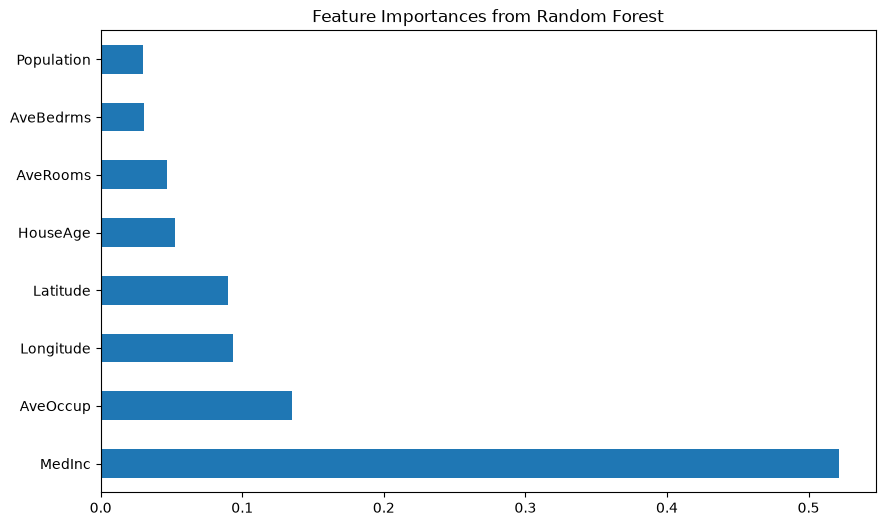

In [92]:
# Visualize feature importances from the Random Forest model
importances = pd.Series(rf.feature_importances_, index=housing.feature_names).sort_values(ascending=False)
importances.plot(kind='barh', figsize=(10, 6), title='Feature Importances from Random Forest')

## Boosting

### Gradient Boosting

In [93]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=SEED)

gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)
rmse_gb = mean_squared_error(y_test, y_pred_gb) ** 0.5
r2_gb = r2_score(y_test, y_pred_gb)
print(f"Gradient Boosting Regressor RMSE: {rmse_gb:.4f}, R^2: {r2_gb:.4f}")

Gradient Boosting Regressor RMSE: 0.5152, R^2: 0.8054


### Stochastic Gradient Boosting

In [94]:
sgbr = GradientBoostingRegressor(n_estimators=200, max_depth=3, subsample=0.8, random_state=SEED)
sgbr.fit(X_train_scaled, y_train)
y_pred_sgbr = sgbr.predict(X_test_scaled)
rmse_sgbr = mean_squared_error(y_test, y_pred_sgbr) ** 0.5
r2_sgbr = r2_score(y_test, y_pred_sgbr)
print(f"Stochastic Gradient Boosting Regressor RMSE: {rmse_sgbr:.4f}, R^2: {r2_sgbr:.4f}")

Stochastic Gradient Boosting Regressor RMSE: 0.5132, R^2: 0.8070


## Model Tuning

In [99]:
# Tuning Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=SEED)

param_grid = {
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [4, 8, 12, 16, 20],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['absolute_error', 'squared_error', 'poisson']
}

grid_search_dt = GridSearchCV(estimator=dt, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3, n_jobs=-1)
grid_search_dt.fit(X_train_scaled, y_train)
y_pred_dt = grid_search_dt.predict(X_test_scaled)


print(f"Best parameters (Decision Tree Regressor): {grid_search_dt.best_params_}")
print(f"Best cross-validation RMSE (Decision Tree Regressor): {(-grid_search_dt.best_score_) ** 0.5:.4f}")
print(f"Test set RMSE (Decision Tree Regressor): {mean_squared_error(y_test, y_pred_dt) ** 0.5:.4f}")
print(f"Test set R^2 (Decision Tree Regressor): {r2_score(y_test, y_pred_dt):.4f}")

Best parameters (Decision Tree Regressor): {'criterion': 'poisson', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 12, 'min_samples_split': 2}
Best cross-validation RMSE (Decision Tree Regressor): 0.6118
Test set RMSE (Decision Tree Regressor): 0.6067
Test set R^2 (Decision Tree Regressor): 0.7302


In [101]:
# Tuning Random Forest Regressor
rf = RandomForestRegressor(random_state=SEED)

print(rf.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 10, 'verbose': 0, 'warm_start': False}


In [104]:
param_grid = {
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [4, 8, 12, 16, 20],
    'max_features': [None, 'sqrt', 'log2'],
}

In [105]:
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3, n_jobs=-1)
grid_search_rf.fit(X_train_scaled, y_train)

print(f"Best parameters (Random Forest Regressor): {grid_search_rf.best_params_}")
print(f"Best cross-validation RMSE (Random Forest Regressor): {(-grid_search_rf.best_score_) ** 0.5:.4f}")
y_pred_rf = grid_search_rf.predict(X_test_scaled)
print(f"Test set RMSE (Random Forest Regressor): {mean_squared_error(y_test, y_pred_rf) ** 0.5:.4f}")
print(f"Test set R^2 (Random Forest Regressor): {r2_score(y_test, y_pred_rf):.4f}")

Best parameters (Random Forest Regressor): {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 4}
Best cross-validation RMSE (Random Forest Regressor): 0.5069
Test set RMSE (Random Forest Regressor): 0.4998
Test set R^2 (Random Forest Regressor): 0.8169
